In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
spam=pd.read_csv('https://raw.githubusercontent.com/SinhaPushkar047/Deep_Learning_Projects/refs/heads/main/Spam_Classifier/spambase_csv.csv')

In [3]:
spam

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


In [4]:
spam.shape

(4601, 58)

# **Train Test Split**

In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(spam.drop(columns='class'),spam['class'],test_size=0.2,random_state=42)

# **MLP**

In [6]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential,Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
x_train.shape

(3680, 57)

In [8]:
model1=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu'),
    Dense(75,activation='relu'),
    Dense(30,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [9]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 150)            │         8,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 75)             │        11,325 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         2,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,336 (87.25 KB)

 Trainable params: 22,336 (87.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model1.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])

In [11]:
history1=model1.fit(x_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Accuracy: 0.6953 - loss: 1.9097 - val_Accuracy: 0.7989 - val_loss: 0.6563
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.7969 - loss: 0.7512 - val_Accuracy: 0.8465 - val_loss: 0.4159
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8353 - loss: 0.6038 - val_Accuracy: 0.8546 - val_loss: 0.5703
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8390 - loss: 0.5489 - val_Accuracy: 0.8315 - val_loss: 0.6175
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8855 - loss: 0.3601 - val_Accuracy: 0.8560 - val_loss: 0.4828
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8665 - loss: 0.4765 - val_Accuracy: 0.8682 - val_loss: 0.3608
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9069 - loss: 0.2815 - val_Accuracy: 0.9144 - val_loss: 0.2098
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8536 - loss: 0.6638 - val_Accuracy: 0.8764 - v

In [12]:
y_prob1=model1.predict(x_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [13]:
y_pred1 = (y_prob1 >= 0.5).astype(int)

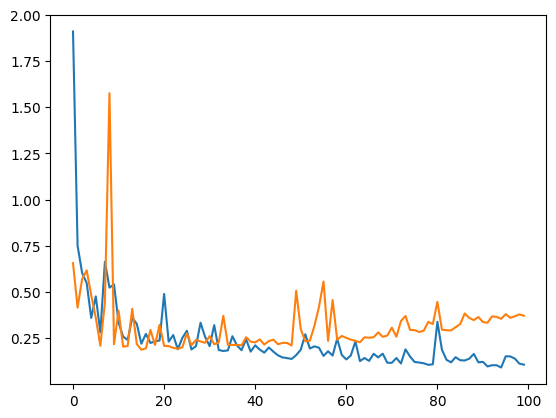

In [14]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])

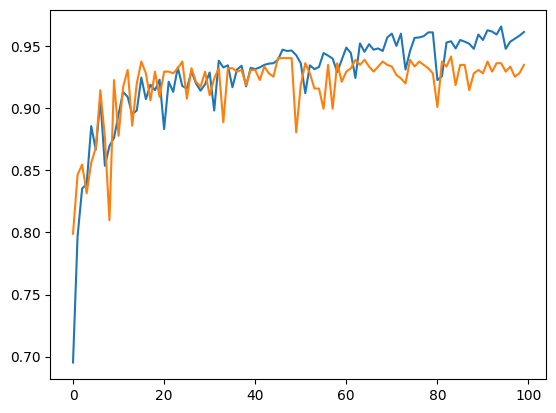

In [15]:
plt.plot(history1.history['Accuracy'])
plt.plot(history1.history['val_Accuracy'])

# **Early Stopping**

In [16]:
model2=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu'),
    Dense(75,activation='relu'),
    Dense(30,activation='relu'),
    Dense(1,activation='sigmoid')
])

In [17]:
model2.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])

In [18]:
callback=EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='min',
    restore_best_weights=True
)

In [19]:
history2=model2.fit(x_train,y_train,epochs=100,batch_size=32,
                   validation_split=0.2,callbacks=[callback])

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - Accuracy: 0.6539 - loss: 1.1797 - val_Accuracy: 0.6671 - val_loss: 1.1183
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Accuracy: 0.7711 - loss: 0.6088 - val_Accuracy: 0.8207 - val_loss: 0.6114
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - Accuracy: 0.8108 - loss: 0.5605 - val_Accuracy: 0.8655 - val_loss: 0.3510
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.8370 - loss: 0.5210 - val_Accuracy: 0.8804 - val_loss: 0.3323
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8675 - loss: 0.3586 - val_Accuracy: 0.8329 - val_loss: 0.5109
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8668 - loss: 0.3609 - val_Accuracy: 0.9062 - val_loss: 0.2757
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8916 - loss: 0.3143 - val_Accuracy: 0.8995 - val_loss: 0.2968
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8740 - loss: 0.3599 - val_Accuracy: 0.9280 - 

In [20]:
y_prob2=model2.predict(x_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [21]:
y_pred2=(y_prob2>=0.5).astype(int)

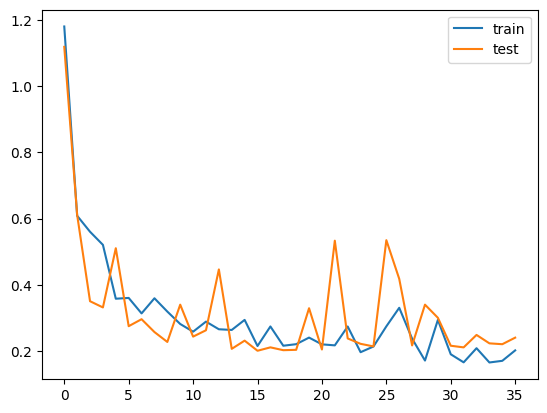

In [22]:
plt.plot(history2.history['loss'],label='train')
plt.plot(history2.history['val_loss'],label='test')
plt.legend()

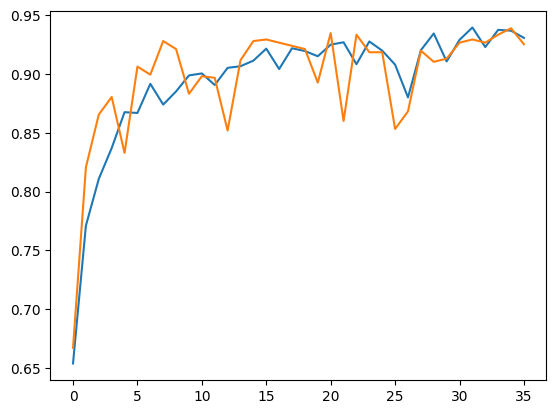

In [23]:
plt.plot(history2.history['Accuracy'])
plt.plot(history2.history['val_Accuracy'])

# **Early Stopping + Scaling**

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
sc=StandardScaler()
x_train_scale=sc.fit_transform(x_train)
x_test_scale=sc.transform(x_test)

In [26]:
model3=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu'),
    Dense(75,activation='relu'),
    Dense(30,activation='relu'),
    Dense(1,activation='sigmoid'),
])

In [27]:
callback=EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    restore_best_weights=True,
    min_delta=0.0001,
    patience=20
)

In [28]:
model3.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])

In [29]:
history3=model3.fit(x_train_scale,y_train,batch_size=32,validation_split=0.2,epochs=100,callbacks=[callback])

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - Accuracy: 0.8954 - loss: 0.3094 - val_Accuracy: 0.9280 - val_loss: 0.2102
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9344 - loss: 0.1894 - val_Accuracy: 0.9389 - val_loss: 0.1855
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.9429 - loss: 0.1582 - val_Accuracy: 0.9293 - val_loss: 0.1878
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9467 - loss: 0.1417 - val_Accuracy: 0.9375 - val_loss: 0.1782
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9558 - loss: 0.1304 - val_Accuracy: 0.9348 - val_loss: 0.1830
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9548 - loss: 0.1147 - val_Accuracy: 0.9361 - val_loss: 0.1870
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9592 - loss: 0.1135 - val_Accuracy: 0.9389 - val_loss: 0.1806
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - Accuracy: 0.9691 - loss: 0.0940 - val_Accuracy: 0.9334 - v

In [30]:
y_prob3=model3.predict(x_test_scale)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [31]:
y_pred3=(y_prob3>=0.5).astype(int)

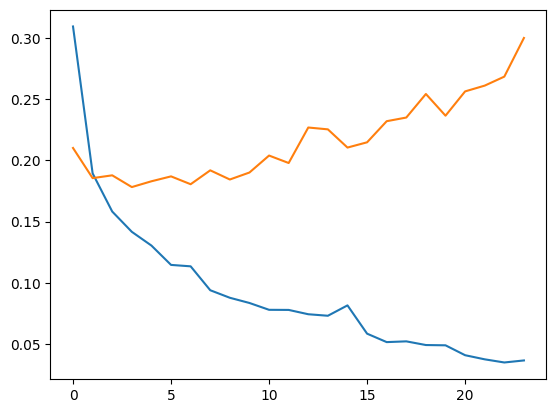

In [32]:
plt.plot(history3.history['loss'],label='train')
plt.plot(history3.history['val_loss'],label='test')

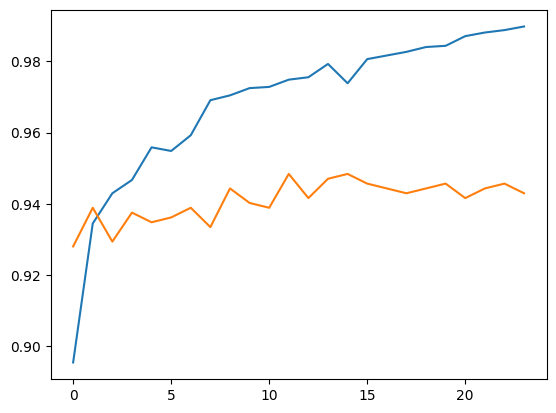

In [33]:
plt.plot(history3.history['Accuracy'])
plt.plot(history3.history['val_Accuracy'])

# **Early Stopping + Scaling + Dropout**

In [34]:
from tensorflow.keras.layers import Dropout

In [35]:
model4=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu'),
    Dropout(0.5),
    Dense(75,activation='relu'),
    Dropout(0.5),
    Dense(30,activation='relu'),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

In [36]:
callback=EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    restore_best_weights=True,
    min_delta=0.001,
    patience=20
)

In [37]:
model4.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['Accuracy'])

In [38]:
history4=model4.fit(x_train_scale,y_train,validation_split=0.2,epochs=100,batch_size=32,callbacks=callback)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - Accuracy: 0.6987 - loss: 0.5942 - val_Accuracy: 0.8886 - val_loss: 0.3560
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8614 - loss: 0.3656 - val_Accuracy: 0.9158 - val_loss: 0.2605
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8937 - loss: 0.3089 - val_Accuracy: 0.9212 - val_loss: 0.2226
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9066 - loss: 0.2834 - val_Accuracy: 0.9280 - val_loss: 0.2150
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9158 - loss: 0.2623 - val_Accuracy: 0.9280 - val_loss: 0.2075
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9158 - loss: 0.2315 - val_Accuracy: 0.9321 - val_loss: 0.2080
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9256 - loss: 0.2241 - val_Accuracy: 0.9307 - val_loss: 0.1958
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9270 - loss: 0.2124 - val_Accuracy: 0.9307 - v

In [39]:
y_prob4=model4.predict(x_test_scale)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [40]:
y_pred4=(y_prob4>=0.5).astype(int)

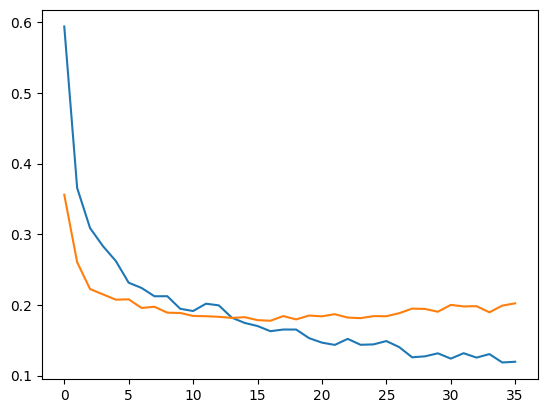

In [41]:
plt.plot(history4.history['loss'],label='train')
plt.plot(history4.history['val_loss'],label='test')

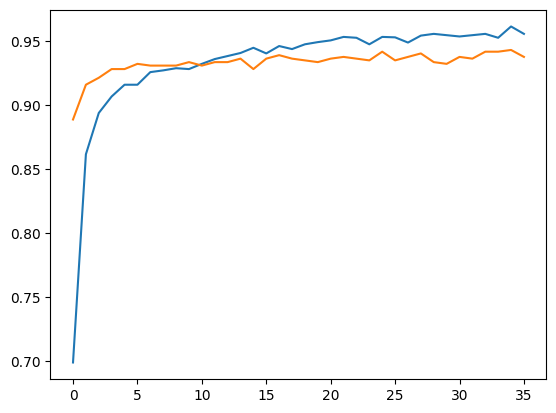

In [42]:
plt.plot(history4.history['Accuracy'],label="Accuracy")
plt.plot(history4.history['val_Accuracy'],label="Val_Accuracy")

# **Early Stopping + Data Scaling + Dropout + Regularization**

In [43]:
model5=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.001, l2=0.001)),
    Dropout(0.5),
    Dense(75,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.001, l2=0.001)),
    Dropout(0.5),
    Dense(30,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.001, l2=0.001)),
    Dropout(0.5),
    Dense(1,activation='sigmoid'),
])

In [44]:
model5.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['Accuracy'])

In [45]:
callback=EarlyStopping(
    monitor='val_loss',
    mode='min',
    restore_best_weights=True,
    verbose=1,
    min_delta=0.001,
    patience=20
)

In [46]:
history5=model5.fit(x_train_scale,y_train,batch_size=32,epochs=100,callbacks=callback,validation_split=0.2,verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - Accuracy: 0.6997 - loss: 2.4812 - val_Accuracy: 0.8736 - val_loss: 2.0484
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8665 - loss: 1.8805 - val_Accuracy: 0.9103 - val_loss: 1.5809
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9066 - loss: 1.4682 - val_Accuracy: 0.9280 - val_loss: 1.2473
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9110 - loss: 1.1620 - val_Accuracy: 0.9293 - val_loss: 0.9909
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9232 - loss: 0.9377 - val_Accuracy: 0.9321 - val_loss: 0.8058
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9239 - loss: 0.7780 - val_Accuracy: 0.9334 - val_loss: 0.6717
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9212 - loss: 0.6632 - val_Accuracy: 0.9321 - val_loss: 0.5831
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.9229 - loss: 0.5754 - val_Accuracy: 0.9348 - 

In [47]:
y_prob5=model5.predict(x_test_scale)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [48]:
y_pred5=(y_prob5>=0.5).astype(int)

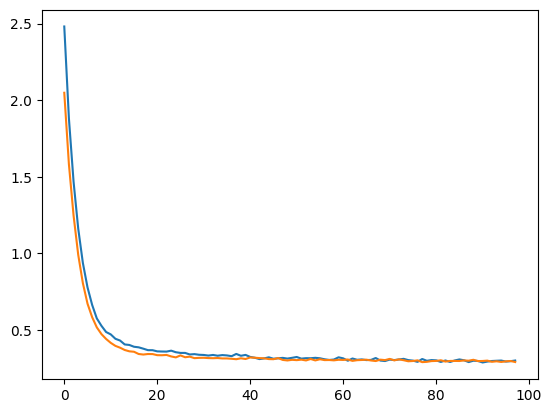

In [49]:
plt.plot(history5.history['loss'],label='train')
plt.plot(history5.history['val_loss'],label='test')

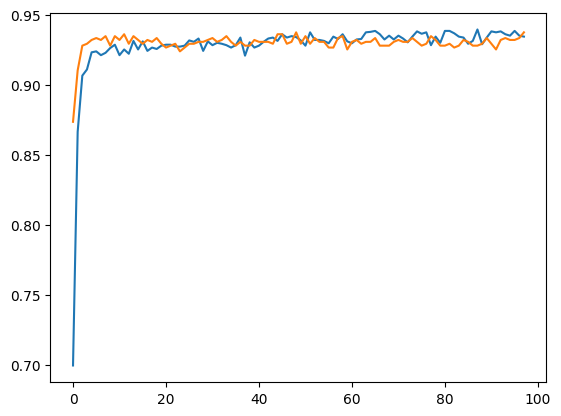

In [50]:
plt.plot(history5.history['Accuracy'],label='Accuracy')
plt.plot(history5.history['val_Accuracy'],label='Val_Accuracy')

# **Early Stopping + Data Scaling + Dropout+ Regulariation + Batch Normalization**

In [51]:
from tensorflow.keras.layers import BatchNormalization

In [52]:
model6=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(
        l1=0.01,l2=0.001
    )),
    BatchNormalization(),
    Dropout(0.5),
    Dense(75,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(
        l1=0.01,l2=0.001
    )),
    BatchNormalization(),
    Dropout(0.5),
    Dense(30,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(
        l1=0.01,l2=0.001
    )),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1,activation='sigmoid'),
])

In [53]:
callback=EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    restore_best_weights=True,
    patience=20,
    min_delta=0.01
)

In [54]:
model6.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])

In [55]:
history6=model6.fit(x_train_scale,y_train,batch_size=32,verbose=1,validation_split=0.2,epochs=100,callbacks=callback)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - Accuracy: 0.6382 - loss: 16.3654 - val_Accuracy: 0.8030 - val_loss: 12.7528
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - Accuracy: 0.7819 - loss: 9.9357 - val_Accuracy: 0.8329 - val_loss: 7.4056
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Accuracy: 0.8431 - loss: 5.4813 - val_Accuracy: 0.8614 - val_loss: 4.0028
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Accuracy: 0.8750 - loss: 2.9573 - val_Accuracy: 0.8614 - val_loss: 2.3436
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Accuracy: 0.8903 - loss: 1.8548 - val_Accuracy: 0.8791 - val_loss: 1.6903
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - Accuracy: 0.8798 - loss: 1.4723 - val_Accuracy: 0.9158 - val_loss: 1.3258
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8835 - loss: 1.2191 - val_Accuracy: 0.9035 - val_loss: 1.1240
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8961 - loss: 1.0016 - val_Accuracy: 0.9130 

In [56]:
y_prob6=model6.predict(x_test_scale)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [57]:
y_pred6=(y_prob6>=0.5).astype(int)

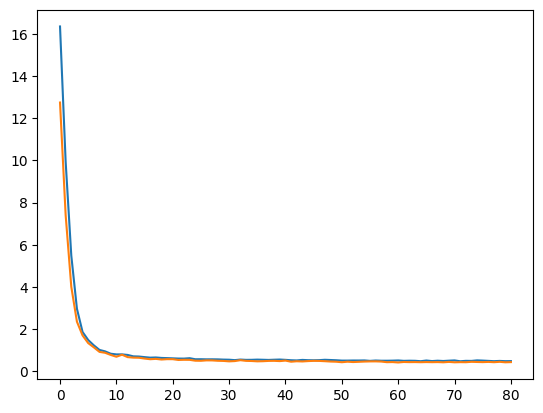

In [58]:
plt.plot(history6.history['loss'],label='Train')
plt.plot(history6.history['val_loss'],label='Test')

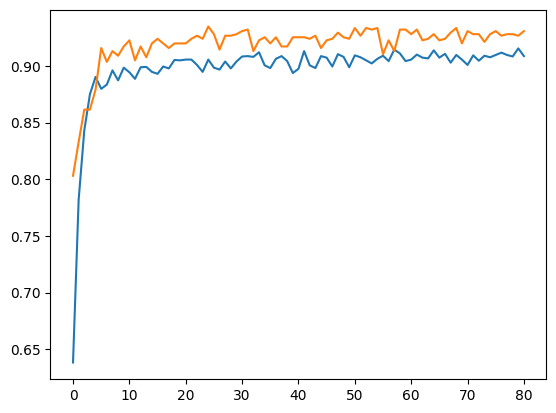

In [59]:
plt.plot(history6.history['Accuracy'],label='Accuracy')
plt.plot(history6.history['val_Accuracy'],label='Val_Accuracy')

# **Early Stopping + Data Scaling + Dropout+ Regulariation + Batch Normalization + Weight Initalization**

In [60]:
model7=Sequential([
    Input(shape=(57,)),
    Dense(150,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.05,l2=0.01),kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(150,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.05,l2=0.01),kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(150,activation='relu',kernel_regularizer=tensorflow.keras.regularizers.L1L2(l1=0.05,l2=0.01),kernel_initializer='he_normal'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

In [61]:
callback=EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    restore_best_weights=True,
    patience=20,
    min_delta=0.01
)

In [62]:
model7.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['Accuracy'])

In [63]:
history7=model7.fit(x_train_scale,y_train,verbose=1,validation_split=0.2,callbacks=callback,epochs=100,batch_size=32)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - Accuracy: 0.5255 - loss: 190.7903 - val_Accuracy: 0.6236 - val_loss: 110.0050
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.6488 - loss: 65.4291 - val_Accuracy: 0.6236 - val_loss: 32.9929
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.7921 - loss: 19.0644 - val_Accuracy: 0.6236 - val_loss: 10.8146
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8526 - loss: 6.8391 - val_Accuracy: 0.6236 - val_loss: 3.9873
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8733 - loss: 2.4539 - val_Accuracy: 0.6236 - val_loss: 1.8938
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8767 - loss: 1.3505 - val_Accuracy: 0.6291 - val_loss: 1.3832
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - Accuracy: 0.8798 - loss: 1.1189 - val_Accuracy: 0.8451 - val_loss: 1.1841
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - Accuracy: 0.8736 - loss: 1.0803 - val_Accuracy: 0

In [64]:
y_prob7=model7.predict(x_test_scale)

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [65]:
y_pred7=(y_prob7>=0.5).astype(int)

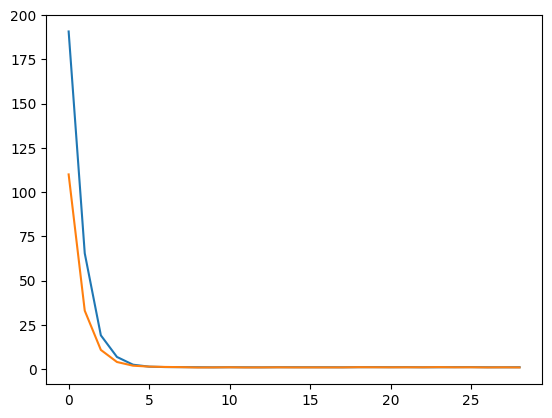

In [66]:
plt.plot(history7.history['loss'],label='train')
plt.plot(history7.history['val_loss'],label='test')

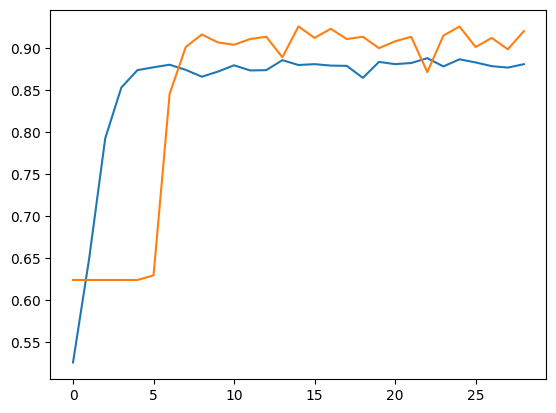

In [67]:
plt.plot(history7.history['Accuracy'],label='Accuracy')
plt.plot(history7.history['val_Accuracy'],label='Val_Accuracy')

# **Comparison**

In [69]:
print("Model 1 : ",classification_report(y_test,y_pred1))
print("Model 1 : ")
confusion_matrix(y_test,y_pred1)

Model 1 :                precision    recall  f1-score   support

           0       0.94      0.96      0.95       531
           1       0.94      0.92      0.93       390

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

Model 1 : 


array([[510,  21],
       [ 31, 359]])

In [70]:
print("Model 2 : ",classification_report(y_test,y_pred2))
print("Model 2 : ")
confusion_matrix(y_test,y_pred2)

Model 2 :                precision    recall  f1-score   support

           0       0.94      0.94      0.94       531
           1       0.92      0.92      0.92       390

    accuracy                           0.93       921
   macro avg       0.93      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921

Model 2 : 


array([[499,  32],
       [ 32, 358]])

In [71]:
print("Model 3 : ",classification_report(y_test,y_pred3))
print("Model 3 : ")
confusion_matrix(y_test,y_pred3)

Model 3 :                precision    recall  f1-score   support

           0       0.95      0.94      0.95       531
           1       0.92      0.93      0.93       390

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

Model 3 : 


array([[501,  30],
       [ 26, 364]])

In [72]:
print("Model 4 : ",classification_report(y_test,y_pred4))
print("Model 4 : ")
confusion_matrix(y_test,y_pred4)

Model 4 :                precision    recall  f1-score   support

           0       0.94      0.95      0.95       531
           1       0.93      0.92      0.93       390

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

Model 4 : 


array([[506,  25],
       [ 31, 359]])

In [73]:
print("Model 5 : ",classification_report(y_test,y_pred5))
print("Model 5 : ")
confusion_matrix(y_test,y_pred5)

Model 5 :                precision    recall  f1-score   support

           0       0.93      0.97      0.95       531
           1       0.95      0.91      0.93       390

    accuracy                           0.94       921
   macro avg       0.94      0.94      0.94       921
weighted avg       0.94      0.94      0.94       921

Model 5 : 


array([[513,  18],
       [ 37, 353]])

In [74]:
print("Model 6 : ",classification_report(y_test,y_pred6))
print("Model 6 : ")
confusion_matrix(y_test,y_pred6)

Model 6 :                precision    recall  f1-score   support

           0       0.92      0.97      0.94       531
           1       0.95      0.89      0.92       390

    accuracy                           0.93       921
   macro avg       0.94      0.93      0.93       921
weighted avg       0.93      0.93      0.93       921

Model 6 : 


array([[513,  18],
       [ 43, 347]])

In [75]:
print("Model 7 : ",classification_report(y_test,y_pred7))
print("Model 7 : ")
confusion_matrix(y_test,y_pred7)

Model 7 :                precision    recall  f1-score   support

           0       0.92      0.95      0.93       531
           1       0.93      0.89      0.91       390

    accuracy                           0.92       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.92      0.92      0.92       921

Model 7 : 


array([[503,  28],
       [ 42, 348]])